# 3D Trajectory Analysis of SIRCmw 

This notebook simulates the SIRCmw system, reduced to a 3-dimensional system using the population conservation property (S + I + R + C = 1) and substituting C = 1 - S - I - R

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import plotly.graph_objects as go
import matplotlib
import sys
from pathlib import Path
# Add parent directory to path to find sircmw_I_utils
sys.path.append(str(Path.cwd().parent))

# details for mptlb 
font = {'size' : 13}
matplotlib.rc('font', **font)

In [7]:
#  parameters
mu    = 0.02        
alpha = 365.0 / 3.0 
delta = 1.0 / 1.61  
gamma = 0.35     
sigma = 0.07874  
beta0 = 200.0   

# eps scaling based on reference initial conditions
scale_factor = 0.001  # I_0 scaling

# common epsilon value (tilde scaled)
tilde_eps = 0.75
eps1 = tilde_eps / scale_factor
eps2 = tilde_eps / scale_factor

print(f"Scaled epsilons: eps1 = eps2 = {eps1:.2f}")


Scaled epsilons: eps1 = eps2 = 750.00


In [8]:
def sircmw_3d_rhs(t, y, eps1, eps2):
    S, I, R = np.maximum(y, 0.0)
    C = np.maximum(1.0 - S - I - R, 0.0)
    dS = mu * (1.0 - S) - beta0 * S * I + (1.0 + eps2 * I) * gamma * C
    dI = beta0 * S * I + sigma * beta0 * C * I - (mu + alpha) * I
    dR = (1.0 - sigma) * beta0 * C * I + alpha * I - mu * R - (1.0 + eps1 * I) * delta * R
    return np.array([dS, dI, dR])

def sircmw_4d_rhs(t, y, eps1, eps2):
    S, I, R, C = np.maximum(y, 0.0)
    dS = mu * (1.0 - S) - beta0 * S * I + (1.0 + eps2 * I) * gamma * C
    dI = beta0 * S * I + sigma * beta0 * C * I - (mu + alpha) * I
    dR = (1.0 - sigma) * beta0 * C * I + alpha * I - mu * R - (1.0 + eps1 * I) * delta * R
    dC = (1.0 + eps1 * I) * delta * R - beta0 * C * I - mu * C - (1.0 + eps2 * I) * gamma * C
    return np.array([dS, dI, dR, dC])

Now we integrate both systems over a span of 100 years from the same initial conditions...


In [9]:
# initial values
S0, I0, R0, C0 = 0.1, 0.01, 0.69, 0.2

y0_3d = np.array([S0, I0, R0])
y0_4d = np.array([S0, I0, R0, C0])

# integration timespan (100 years)
t_span = (0.0, 100.0)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

def integrate_with_reseeding_3d(rhs, t_span, y0, eps1, eps2, *, threshold=0.2 * scale_factor,
                                 I_seed=scale_factor, max_events=10000, **solver_kw):
    t0, tf = t_span

    def hit_floor(t, y, eps1, eps2):
        return y[1] - threshold
    hit_floor.terminal  = True
    hit_floor.direction = -1

    ts, ys = [], []
    y = np.asarray(y0, float)
    t_start, n_ev = t0, 0
    p = {'beta0': beta0, 'sigma': sigma, 'eps': eps1}

    while t_start < tf:
        sol = solve_ivp(rhs, (t_start, tf), y, args=(eps1, eps2),
                        events=hit_floor, method='DOP853', **solver_kw)
        ts.append(sol.t)
        ys.append(sol.y)

        if sol.status == 1 and sol.t_events[0].size:
            t_ev = sol.t_events[0][-1]
            y_ev = sol.y_events[0][-1].copy()
            
            S_ev, I_ev, R_ev = y_ev
            C_ev = 1.0 - S_ev - I_ev - R_ev
            y_ev_4d = np.array([S_ev, I_ev, R_ev, C_ev])
            
            from sircmw_I_utils import infection_eigvec
            v, _ = infection_eigvec(y_ev_4d, t_ev, p)
            v_3d = v[:3]
            y = y_ev + (I_seed - y_ev[1]) * v_3d
            y = np.clip(y, 0.0, None)
            y_sum = y.sum()
            if y_sum > 1.0:
                y = y / y_sum
            
            t_start = t_ev
            n_ev += 1
            if n_ev > max_events:
                break
        else:
            break

    t_arr = np.concatenate(ts)
    Y_arr = np.concatenate(ys, axis=1)
    t_arr, idx = np.unique(t_arr, return_index=True)
    return t_arr, Y_arr[:, idx]

def integrate_with_reseeding_4d(rhs, t_span, y0, eps1, eps2, *, threshold=0.2 * scale_factor,
                                 I_seed=scale_factor, max_events=10000, **solver_kw):
    t0, tf = t_span

    def hit_floor(t, y, eps1, eps2):
        return y[1] - threshold
    hit_floor.terminal  = True
    hit_floor.direction = -1

    ts, ys = [], []
    y = np.asarray(y0, float)
    t_start, n_ev = t0, 0
    p = {'beta0': beta0, 'sigma': sigma, 'eps': eps1}

    while t_start < tf:
        sol = solve_ivp(rhs, (t_start, tf), y, args=(eps1, eps2),
                        events=hit_floor, method='DOP853', **solver_kw)
        ts.append(sol.t)
        ys.append(sol.y)

        if sol.status == 1 and sol.t_events[0].size:
            t_ev = sol.t_events[0][-1]
            y_ev = sol.y_events[0][-1].copy()
            
            from sircmw_I_utils import infection_eigvec
            v, _ = infection_eigvec(y_ev, t_ev, p)
            y = y_ev + (I_seed - y_ev[1]) * v
            y = np.clip(y, 0.0, None)
            y = y / y.sum()
            
            t_start = t_ev
            n_ev += 1
            if n_ev > max_events:
                break
        else:
            break

    t_arr = np.concatenate(ts)
    Y_arr = np.concatenate(ys, axis=1)
    t_arr, idx = np.unique(t_arr, return_index=True)
    return t_arr, Y_arr[:, idx]

# Integrate using local functions with reseeding
t_arr_3d, Y_arr_3d = integrate_with_reseeding_3d(sircmw_3d_rhs, t_span, y0_3d, eps1, eps2, rtol=1e-8, atol=1e-10)
t_arr_4d, Y_arr_4d = integrate_with_reseeding_4d(sircmw_4d_rhs, t_span, y0_4d, eps1, eps2, rtol=1e-8, atol=1e-10)

# Interpolate solutions to the common t_eval grid for plotting
from scipy.interpolate import interp1d
S_3d = interp1d(t_arr_3d, Y_arr_3d[0], kind='cubic')(t_eval)
I_3d = interp1d(t_arr_3d, Y_arr_3d[1], kind='cubic')(t_eval)
R_3d = interp1d(t_arr_3d, Y_arr_3d[2], kind='cubic')(t_eval)
C_3d = 1.0 - S_3d - I_3d - R_3d

S_4d = interp1d(t_arr_4d, Y_arr_4d[0], kind='cubic')(t_eval)
I_4d = interp1d(t_arr_4d, Y_arr_4d[1], kind='cubic')(t_eval)
R_4d = interp1d(t_arr_4d, Y_arr_4d[2], kind='cubic')(t_eval)
C_4d = interp1d(t_arr_4d, Y_arr_4d[3], kind='cubic')(t_eval)

max_diff_S = np.max(np.abs(S_3d - S_4d))
max_diff_I = np.max(np.abs(I_3d - I_4d))
max_diff_R = np.max(np.abs(R_3d - R_4d))
max_diff_C = np.max(np.abs(C_3d - C_4d))

print("Equivalence Check (Maximum Absolute Difference with Reseeding):")
print(f"  S(t): {max_diff_S:.2e}")
print(f"  I(t): {max_diff_I:.2e}")
print(f"  R(t): {max_diff_R:.2e}")
print(f"  C(t): {max_diff_C:.2e}")


Equivalence Check (Maximum Absolute Difference with Reseeding):
  S(t): 1.65e-05
  I(t): 1.54e-05
  R(t): 1.06e-03
  C(t): 1.04e-03


We plot the compartment trajectories over time to verify that the algebraic 3D system and the 4D system match

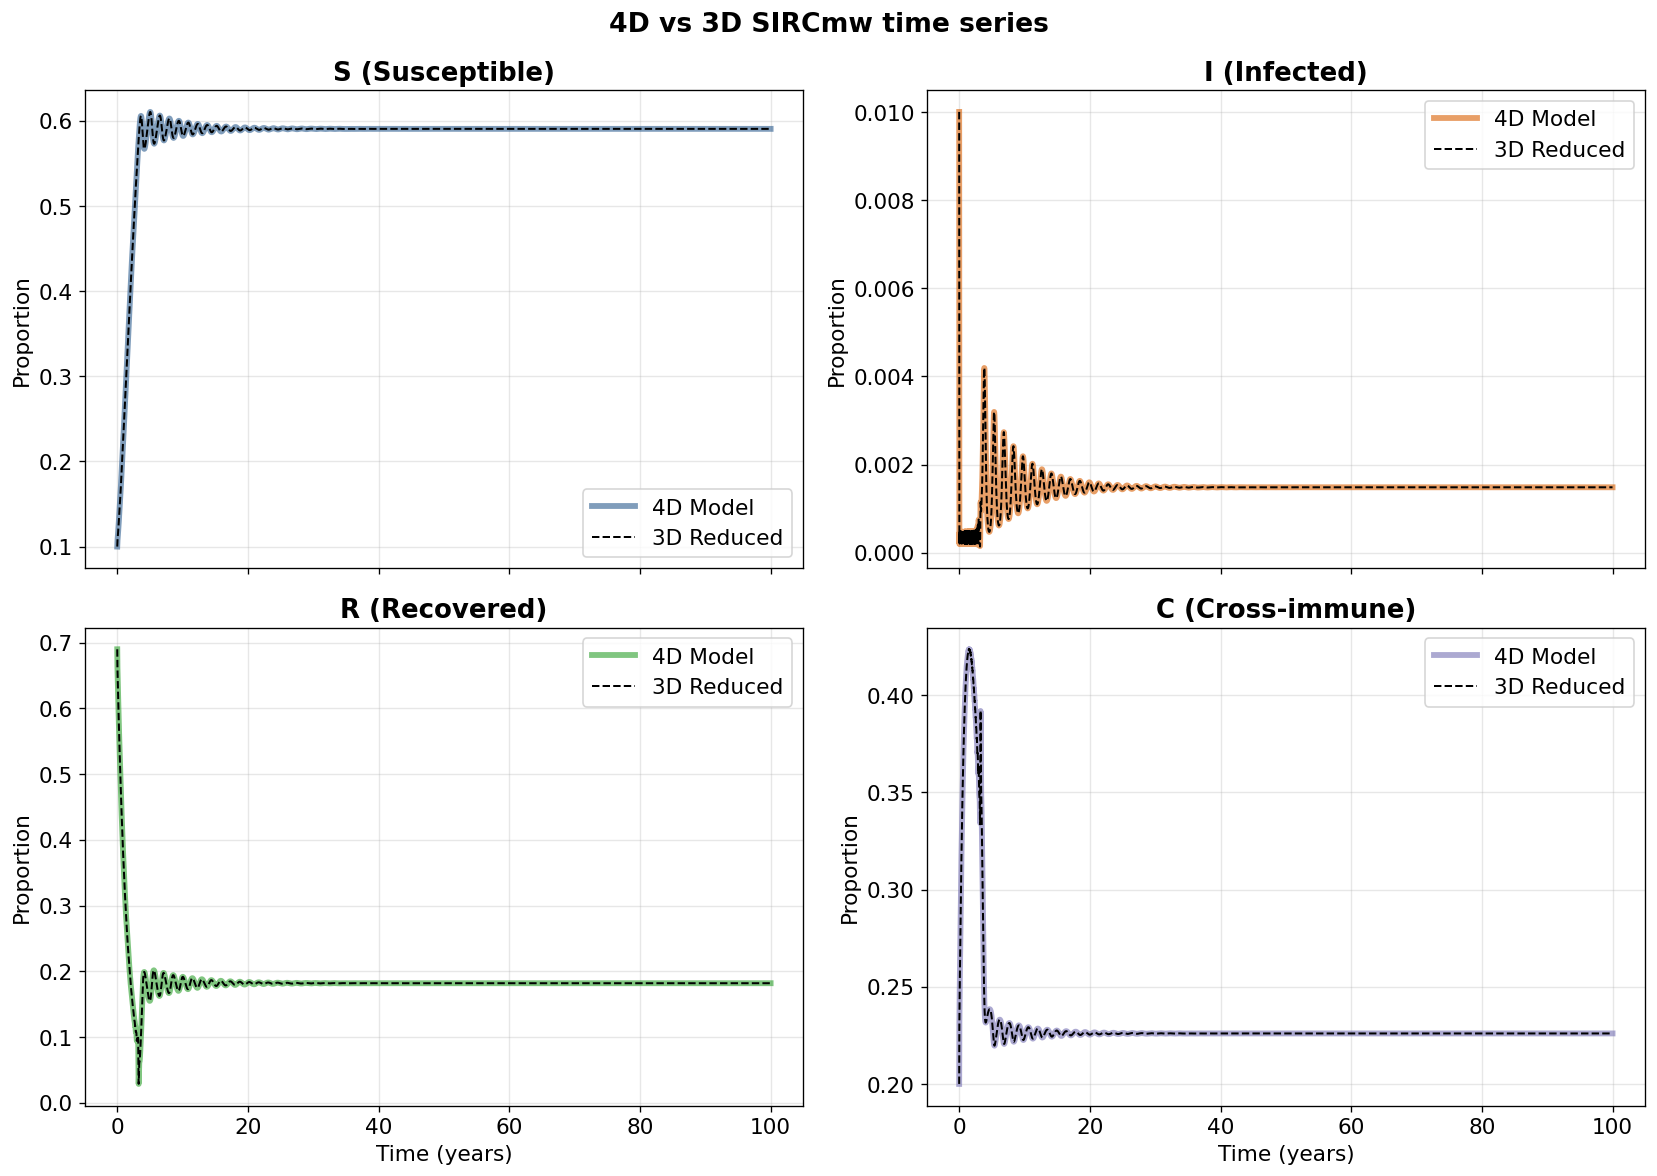

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, dpi=120)
colors = ['#2b5c8f', '#d95f02', '#2ca02c', '#7570b3']
titles = ['S (Susceptible)', 'I (Infected)', 'R (Recovered)', 'C (Cross-immune)']

# plot compartments
for i, (y_4d_vals, y_3d_vals, color, title) in enumerate([
    (S_4d, S_3d, colors[0], titles[0]),
    (I_4d, I_3d, colors[1], titles[1]),
    (R_4d, R_3d, colors[2], titles[2]),
    (C_4d, C_3d, colors[3], titles[3])
]):
    ax = axes[i // 2, i % 2]
    ax.plot(t_eval, y_4d_vals, label='4D Model', color=color, alpha=0.6, lw=3.5)
    ax.plot(t_eval, y_3d_vals, label='3D Reduced', color='black', ls='--', lw=1.2)
    ax.set_ylabel('Proportion')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    if i >= 2:
        ax.set_xlabel('Time (years)')

plt.suptitle('4D vs 3D SIRCmw time series', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

Interactive 3D Trajectory 

In [11]:
# set limits based on data plus padding
pad = 0.05
S_min, S_max = S_3d.min(), S_3d.max()
I_min, I_max = I_3d.min(), I_3d.max()
R_min, R_max = R_3d.min(), R_3d.max()

xlim = [S_min - pad*(S_max-S_min), S_max + pad*(S_max-S_min)]
ylim = [I_min - pad*(I_max-I_min), I_max + pad*(I_max-I_min)]
zlim = [R_min - pad*(R_max-R_min), R_max + pad*(R_max-R_min)]

# 3D trajectory
trace_3d = go.Scatter3d(
    x=S_3d,
    y=I_3d,
    z=R_3d,
    mode='lines',
    line=dict(
        color=t_eval,
        colorscale='Plasma',
        width=5,
        colorbar=dict(title='Time (years)', len=0.6)
    ),
    name='Trajectory',
    hovertemplate='S: %{x:.4f}<br>I: %{y:.4f}<br>R: %{z:.4f}<br>Time in yrs<extra></extra>',
    text=t_eval
)

# start and end points
start_marker = go.Scatter3d(
    x=[S_3d[0]], y=[I_3d[0]], z=[R_3d[0]],
    mode='markers',
    marker=dict(size=4, color='#2ca02c', line=dict(color='black', width=1)),
    name='Start (t=0)'
)
end_marker = go.Scatter3d(
    x=[S_3d[-1]], y=[I_3d[-1]], z=[R_3d[-1]],
    mode='markers',
    marker=dict(size=4, color='#d62728', line=dict(color='black', width=1)),
    name='End (t=100)'
)

# projections 
si_proj = go.Scatter3d(
    x=S_3d, y=I_3d, z=np.ones_like(R_3d)*zlim[0],
    mode='lines', line=dict(color='gray', width=2, dash='dash'),
    name='S-I Projection', opacity=0.4, hoverinfo='skip'
)
ir_proj = go.Scatter3d(
    x=np.ones_like(S_3d)*xlim[0], y=I_3d, z=R_3d,
    mode='lines', line=dict(color='gray', width=2, dash='dot'),
    name='I-R Projection', opacity=0.4, hoverinfo='skip'
)
sr_proj = go.Scatter3d(
    x=S_3d, y=np.ones_like(I_3d)*ylim[1], z=R_3d,
    mode='lines', line=dict(color='gray', width=2, dash='dashdot'),
    name='S-R Projection', opacity=0.4, hoverinfo='skip'
)

# layout setup
layout = go.Layout(
    title=dict(text=' 3D Trajectory of SIRCmw', font=dict(size=18, weight='bold'), y=0.95),
    scene=dict(
        xaxis=dict(title='S (Susceptible)', range=xlim),
        yaxis=dict(title='I (Infected)', range=ylim),
        zaxis=dict(title='R (Recovered)', range=zlim),
        camera=dict(eye=dict(x=1.6, y=-1.6, z=1.3))
    ),
    width=900,
    height=800,
    margin=dict(l=0, r=0, b=0, t=80),
    legend=dict(x=0.8, y=0.9)
)

fig = go.Figure(data=[trace_3d, start_marker, end_marker, si_proj, ir_proj, sr_proj], layout=layout)
fig.show()

In [12]:
print(f"Initial [S, I, R, C] = [{S_3d[0]:.6f}, {I_3d[0]:.6f}, {R_3d[0]:.6f}, {C_3d[0]:.6f}]")
print(f"Final   [S, I, R, C] = [{S_3d[-1]:.6f}, {I_3d[-1]:.6f}, {R_3d[-1]:.6f}, {C_3d[-1]:.6f}]")

Initial [S, I, R, C] = [0.100000, 0.010000, 0.690000, 0.200000]
Final   [S, I, R, C] = [0.590639, 0.001484, 0.181893, 0.225983]
